# **AutoDiff Engine**

AutoDiff Engine - Based on Medium article by Bhavya Sankhla et al.\
"DIY Deep Learning: Crafting Your Own Autograd Engine from Scratch"

*Author     -     Felix Niklas Regler\
Matr. Nr.  -     9445603*

*Co-Authors  -   Tom Weber & Gina Grünen*

In [34]:
import math

from graphviz import Digraph

### **AUTODIFF Klasse**

In [41]:
class Tensor:
    """
    Wrapper for scalar values with automatic differentiation.
    Builds computation graph and calculates gradients via backprop.
    """
    
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Tensor(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only int/float powers"
        out = Tensor(self.data ** other, (self,), f'**{other}')
        
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out
    
    def __neg__(self):
        return self * -1
    
    def __radd__(self, other):
        return self + other
    
    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):
        return other + (-self)
    
    def __rmul__(self, other):
        return self * other
    
    def __truediv__(self, other):
        return self * other ** -1
    
    def __rtruediv__(self, other):
        return other * self ** -1
    
    # === Activation Functions ===

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Tensor(t, (self,), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def relu(self):
        """Rectified Linear Unit activation."""
        out = Tensor(max(0, self.data), (self,), 'relu')
        
        def _backward():
            self.grad += (self.data > 0) * out.grad
        out._backward = _backward
        return out

    def sigmoid(self):
        """Sigmoid activation."""
        s = 1 / (1 + math.exp(-self.data))
        out = Tensor(s, (self,), 'sigmoid')
        
        def _backward():
            self.grad += s * (1 - s) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        """Exponential function."""
        out = Tensor(math.exp(self.data), (self,), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def log(self):
        """Natural logarithm."""
        out = Tensor(math.log(self.data), (self,), 'log')
        
        def _backward():
            self.grad += (1 / self.data) * out.grad
        out._backward = _backward
        return out
        

    # === Backpropagation and Graph Traversal ===
    
    def backward(self):
        """Backprop through graph using topological sort."""
        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    
    def find(self, label):
        """Find tensor by label in graph."""
        visited = set()
        
        def search(node):
            if node in visited:
                return None
            visited.add(node)
            if node.label == label:
                return node
            for child in node._prev:
                found = search(child)
                if found:
                    return found
            return None
        return search(self)

### **Visualisation**

In [ ]:
def trace(root):
    """Build set of all nodes and edges in graph."""
    nodes, edges = set(), set()
    
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges


def draw_dot(root, format='svg', rankdir='LR'):
    """Visualize computation graph with Graphviz."""
    try:
        from graphviz import Digraph
        
        assert rankdir in ['LR', 'TB']
        nodes, edges = trace(root)
        dot = Digraph(format=format, graph_attr={'rankdir': rankdir})
        
        for n in nodes:
            uid = str(id(n))
            dot.node(
                name=uid,
                label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
                shape='record'
            )
            if n._op:
                dot.node(name=uid + n._op, label=n._op)
                dot.edge(uid + n._op, uid)
        
        for n1, n2 in edges:
            dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
        return dot
    
    except Exception as e:
        print(f"Graphviz error: {e}")
        return None

### **Test Case from Assignment**

In [37]:
def nn(vals):
    
    # inputs
    x1 = Tensor(vals[0], label='x1')
    x2 = Tensor(vals[1], label='x2')

    # weights w1, w2
    w1 = Tensor(-3.0, label='w1')
    w2 = Tensor(1.0, label='w2')

    # bias
    b = Tensor(7.0, label='b')

    # forward pass
    x1w1 = x1 * w1; x1w1.label = 'x1*w1'
    x2w2 = x2 * w2; x2w2.label = 'x2*w2'
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1+x2w2'
    z = x1w1x2w2 + b; z.label = 'z'  # pre-activation
    a = z.tanh(); a.label = 'a'  # activation

    return a

0.8399486832280523


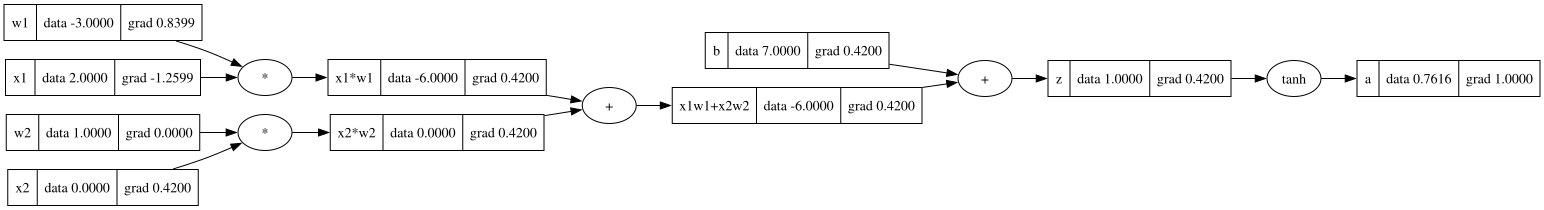

In [38]:
nn1 = nn([2.0, 0.0])
nn1.backward()

# Result
print(nn1.find("w1").grad)  # 0.84 grad of weight w1

# Visualization
draw_dot(nn1)

## **Some more Examples**

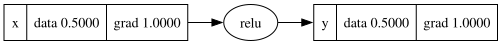

In [64]:
x1 = Tensor(0.5, label='x')
y1 = x1.relu()
y1.label = 'y'
y1.backward()
draw_dot(y1)

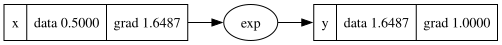

In [66]:
x2 = Tensor(0.5, label='x')
y2 = x2.exp()
y2.label = 'y'
y2.backward()
draw_dot(y2)